# **Identifying Key Entities in Recipe Data**


**Objective**:
The goal of this exercise is to train a Named Entity Recognition (NER) model using Conditional Random Fields (CRF) to extract key entities from recipe data. The model will classify words into predefined categories such as ingredients, quantities and units, enabling the creation of a structured database of recipes and ingredients that can be used to power advanced features in recipe management systems, dietary tracking apps, or e-commerce platforms.

### **Data Description**
The given data is in JSON format, representing a **structured recipe ingredient list** with **Named Entity Recognition (NER) labels**. Below is a breakdown of the data fields:

```json
[
    {
        "input": "6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil",
        "pos": "quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient"
    },
    {
      "input": "2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida",
      "pos": "quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient"
    }
]


| **Key**  | **Description**  |
|----------|-----------------|
| `input`  | Contains a raw ingredient list from a recipe. |
| `pos`    | Represents the corresponding part-of-speech (POS) tags or NER labels, identifying quantities, ingredients, and units. |


## **1** Import libraries

#### **1.1** Installation of sklearn-crfsuite

sklearn-crfsuite is a Python wrapper for CRFsuite, a fast and efficient implementation of Conditional Random Fields (CRFs). It is designed to integrate seamlessly with scikit-learn for structured prediction tasks such as Named Entity Recognition (NER), Part-of-Speech (POS) tagging, and chunking.

In [ ]:
# installation of sklearn_crfsuite
!pip install sklearn_crfsuite==0.5.0

#### **1.2** Import necessary libraries

In [2]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Import necessary libraries
import json  # For handling JSON data
import pandas as pd  # For data manipulation and analysis
import re  # For regular expressions (useful for text preprocessing)
import matplotlib.pyplot as plt  # For visualisation
import seaborn as sns  # For advanced data visualisation
import sklearn_crfsuite  # CRF (Conditional Random Fields) implementation for sequence modeling
import numpy as np  # For numerical computations
# Saving and loading machine learning models
import joblib
import random
import spacy
from IPython.display import display, Markdown # For displaying well-formatted output

from fractions import Fraction  # For handling fractional values in numerical data
# Importing tools for feature engineering and model training
from collections import Counter  # For counting occurrences of elements in a list
from sklearn.model_selection import train_test_split  # For splitting dataset into train and test sets
from sklearn_crfsuite import metrics  # For evaluating CRF models
from sklearn_crfsuite.metrics import flat_classification_report
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from sklearn.metrics import confusion_matrix

In [4]:
# Ensure pandas displays full content
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

## **2** Data Ingestion and Preparation  <br>

#### **2.1** *Read Recipe Data from Dataframe and prepare the data for analysis*  <br>
Read the data from JSON file, print first five rows and describe the dataframe

##### **2.1.1** **Define a *load_json_dataframe* function**  <br>

Define a function that takes path of the ingredient_and_quantity.json file and reads it, convert it into dataframe - df and return it.

In [5]:
# define a function to load json file to a dataframe

# Function to load JSON dataset into pandas dataframe
def load_json_dataframe(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    return df


##### **2.1.2** **Execute the *load_json_dataframe* function**  <br>

In [6]:
# read the json file by giving the file path and create a dataframe

# Load dataset
df = load_json_dataframe("ingredient_and_quantity.json")



##### **2.1.3** **Describe the dataframe**  <br>

Print first five rows of dataframe along with dimensions. Display the information of dataframe

In [7]:
# display first five rows of the dataframe - df

# Display first five rows
display(df.head())


,input,pos
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient ingredient quantity unit ingredient quantity unit ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
4,1 tablespoon chana dal white urad 2 red chillies coriander seeds 3 inches ginger onion tomato Teaspoon mustard asafoetida sprig curry,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient unit ingredient


In [8]:
# print the dimensions of dataframe - df

# Print dataframe dimensions
print("DataFrame Dimensions:", df.shape)

DataFrame Dimensions: (285, 2)


In [9]:
# print the information of the dataframe

# Display dataframe information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   input   285 non-null    object
 1   pos     285 non-null    object
dtypes: object(2)
memory usage: 4.6+ KB


#### **2.2** *Recipe Data Manipulation* 
Create derived metrics in dataframe and provide insights of the dataframe

##### **2.2.1** **Create input_tokens and pos_tokens columns by splitting the input and pos from the dataframe** <br>
Split the input and pos into input_tokens and pos_tokens in the dataframe and display it in the dataframe

In [10]:
# split the input and pos into input_tokens and pos_tokens in the dataframe

# Tokenize input

# Tokenize input column
df["input_tokens"] = df["input"].apply(lambda x: x.split())

# Tokenize POS

# Tokenize POS labels
df["pos_tokens"] = df["pos"].apply(lambda x: x.split())



In [11]:
# display first five rows of the dataframe - df

# Display first five rows
display(df.head())

,input,pos,input_tokens,pos_tokens
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[6, Karela, Bitter, Gourd, Pavakkai, Salt, 1, Onion, 3, tablespoon, Gram, flour, besan, 2, teaspoons, Turmeric, powder, Haldi, Red, Chilli, Cumin, seeds, Jeera, Coriander, Powder, Dhania, Amchur, Dry, Mango, Sunflower, Oil]","[quantity, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]"
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient,"[2-1/2, cups, rice, cooked, 3, tomatoes, teaspoons, BC, Belle, Bhat, powder, 1, teaspoon, chickpea, lentils, 1/2, cumin, seeds, white, urad, dal, mustard, green, chilli, dry, red, 2, cashew, or, peanuts, 1-1/2, tablespoon, oil, asafoetida]","[quantity, unit, ingredient, ingredient, quantity, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient]"
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient,"[1-1/2, cups, Rice, Vermicelli, Noodles, Thin, 1, Onion, sliced, 1/2, cup, Carrots, Gajjar, chopped, 1/3, Green, peas, Matar, 2, Chillies, 1/4, teaspoon, Asafoetida, hing, Mustard, seeds, White, Urad, Dal, Split, Ghee, sprig, Curry, leaves, Salt, Lemon, juice]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient]"
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient ingredient qua

##### **2.2.2** **Provide the length for input_tokens and pos_tokens and validate their length**  <br>

Create input_length and pos_length columns in the dataframe and validate both the lengths. Check for the rows that are unequal in input and pos length


In [12]:
# create input_length and pos_length columns for the input_tokens and pos-tokens

# Create length columns
df["input_length"] = df["input_tokens"].apply(len)
df["pos_length"] = df["pos_tokens"].apply(len)


In [13]:
# check for the equality of input_length and pos_length in the dataframe

# Check rows where lengths do not match
length_mismatch = df[df["input_length"] != df["pos_length"]]

# Display mismatched rows if any
display(length_mismatch)

,input,pos,input_tokens,pos_tokens,input_length,pos_length
17,2 cups curd 1 cup gourd cucumber green cor coriander 1/2 teaspoon cumin powder salt,quantity unit ingredient quantity unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient,"[2, cups, curd, 1, cup, gourd, cucumber, green, cor, coriander, 1/2, teaspoon, cumin, powder, salt]","[quantity, unit, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient]",15,14
27,1 Baguette sliced 1 1/2 tablespoon Butter 1/2 Garlic minced cup Spinach Leaves Palak Red Bell pepper Capsicum Tomato finely chopped Onion Black powder Italian seasoning teaspoon Fresh cream Cheddar cheese grated Salt Roasted tomato pasta sauce,quantity ingredient ingredient quantity unit ingredient quantity ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[1, Baguette, sliced, 1, 1/2, tablespoon, Butter, 1/2, Garlic, minced, cup, Spinach, Leaves, Palak, Red, Bell, pepper, Capsicum, Tomato, finely, chopped, Onion, Black, powder, Italian, seasoning, teaspoon, Fresh, cream, Cheddar, cheese, grated, Salt, Roasted, tomato, pasta, sauce]","[quantity, ingredient, ingredient, quantity, unit, ingredient, quantity, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",37,36
79,1/2 cup Poha Flattened rice 2 tablespoons Rice flour 2 1/2 liter Milk 1 Nolen Gur or brown sugar Cardamom Elaichi Pods/Seeds 8-10 Mixed nuts almonds/cashews tablespoon Raisins pinch Saffron strands and a little more for garnish Salt,quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient quantity unit ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient unit ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[1/2, cup, Poha, Flattened, rice, 2, tablespoons, Rice, flour, 2, 1/2, liter, Milk, 1, Nolen, Gur, or, brown, sugar, Cardamom, Elaichi, Pods/Seeds, 8-10, Mixed, nuts, almonds/cashews, tablespoon, Raisins, pinch, Saffron, strands, and, a, little, more, for, garnish, Salt]","[quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, unit, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, unit, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",38,37
164,1/2 cup All Purpose Flour Maida Whole Wheat 1/4 Hung Curd Greek Yogurt 250 grams Chicken minced 1 Spinach Leaves Palak finely chopped Onion 4 cloves Garlic Tomatoes tablespoon Cumin powder Jeera Coriander Powder Dhania 1 1/2 teaspoon Paprika Black pepper 3 sprig Mint Pudina 10 Spring Bulb & Greens 100 Feta Cheese crumbled,quantity unit ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient,"[

##### **2.2.3** **Define a unique_labels function and validate the labels in pos_tokens**  <br>

Define a unique_labels function which checks for all the unique pos labels in the recipe & execute it.


In [14]:
# Define a unique_labels function to checks for all the unique pos labels in the recipe & print it

# Function to extract unique POS labels
def unique_labels(df):
    labels = set()
    
    for pos_list in df["pos_tokens"]:
        labels.update(pos_list)
    
    print("Unique POS Labels:", labels)

# Execute function
unique_labels(df)

Unique POS Labels: {'ingredient', 'unit', 'quantity'}


##### **2.2.3** **Provide the insights seen in the recipe data after validation**  <br>

Provide the indexes that requires cleaning and formatting in the dataframe

<font color = red>[write your answer]</font> <br>

After validating the dataset by comparing input_length and pos_length, we checked whether the number of tokens in the input text matches the number of POS labels for every row. This validation is important because a Named Entity Recognition (NER) model requires a one-to-one mapping between tokens and labels.

During this validation step, some rows were identified where the number of input tokens does not match the number of POS labels. This mismatch indicates that the data in those rows is incorrectly formatted or partially labelled, which can cause errors during model training.

Such rows need cleaning or removal before further processing because the CRF model expects each token in a sentence to have a corresponding label.

##### **2.2.4** **Drop the rows that have invalid data provided in previous cell**  <br>

In [15]:
# drop the irrelevant recipe data

# Drop rows where token length and label length do not match
df = df[df["input_length"] == df["pos_length"]]

# Reset index after dropping rows
df = df.reset_index(drop=True)

# Display first five rows after cleaning
display(df.head())

,input,pos,input_tokens,pos_tokens,input_length,pos_length
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[6, Karela, Bitter, Gourd, Pavakkai, Salt, 1, Onion, 3, tablespoon, Gram, flour, besan, 2, teaspoons, Turmeric, powder, Haldi, Red, Chilli, Cumin, seeds, Jeera, Coriander, Powder, Dhania, Amchur, Dry, Mango, Sunflower, Oil]","[quantity, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",31,31
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient,"[2-1/2, cups, rice, cooked, 3, tomatoes, teaspoons, BC, Belle, Bhat, powder, 1, teaspoon, chickpea, lentils, 1/2, cumin, seeds, white, urad, dal, mustard, green, chilli, dry, red, 2, cashew, or, peanuts, 1-1/2, tablespoon, oil, asafoetida]","[quantity, unit, ingredient, ingredient, quantity, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient]",34,34
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient,"[1-1/2, cups, Rice, Vermicelli, Noodles, Thin, 1, Onion, sliced, 1/2, cup, Carrots, Gajjar, chopped, 1/3, Green, peas, Matar, 2, Chillies, 1/4, teaspoon, Asafoetida, hing, Mustard, seeds, White, Urad, Dal, Split, Ghee, sprig, Curry, leaves, Salt, Lemon, juice]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient]",37,37
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient

##### **2.2.5** **Update the input_length & pos_length in dataframe** <br>

In [16]:
# update the input and pos length in input_length and pos_length

# Recalculate token lengths after cleaning
df["input_length"] = df["input_tokens"].apply(len)
df["pos_length"] = df["pos_tokens"].apply(len)

# Display first five rows to confirm update
display(df.head())

,input,pos,input_tokens,pos_tokens,input_length,pos_length
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[6, Karela, Bitter, Gourd, Pavakkai, Salt, 1, Onion, 3, tablespoon, Gram, flour, besan, 2, teaspoons, Turmeric, powder, Haldi, Red, Chilli, Cumin, seeds, Jeera, Coriander, Powder, Dhania, Amchur, Dry, Mango, Sunflower, Oil]","[quantity, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",31,31
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient,"[2-1/2, cups, rice, cooked, 3, tomatoes, teaspoons, BC, Belle, Bhat, powder, 1, teaspoon, chickpea, lentils, 1/2, cumin, seeds, white, urad, dal, mustard, green, chilli, dry, red, 2, cashew, or, peanuts, 1-1/2, tablespoon, oil, asafoetida]","[quantity, unit, ingredient, ingredient, quantity, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient]",34,34
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient,"[1-1/2, cups, Rice, Vermicelli, Noodles, Thin, 1, Onion, sliced, 1/2, cup, Carrots, Gajjar, chopped, 1/3, Green, peas, Matar, 2, Chillies, 1/4, teaspoon, Asafoetida, hing, Mustard, seeds, White, Urad, Dal, Split, Ghee, sprig, Curry, leaves, Salt, Lemon, juice]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient]",37,37
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient

##### **2.2.6** **Validate the input_length and pos_length by checking unequal rows**  <br>

In [17]:
# validate the input length and pos length as input_length and pos_length

# Validate that token length and label length are equal
length_validation = (df["input_length"] == df["pos_length"]).all()

print("All rows have equal input and POS lengths:", length_validation)

All rows have equal input and POS lengths: True


## **3** Train Validation Split (70 train - 30 val)  <br>

#### **3.1** *Perform train and validation split ratio*  <br>
Split the dataset with the help of input_tokens and pos_tokens and make a ratio of 70:30 split for training and validation datasets.

###### **3.1.1** **Split the dataset into train_df and val_df into 70:30 ratio**  <br>

In [18]:
# split the dataset into training and validation sets

# Split dataset into training and validation sets (70:30)
train_df, val_df = train_test_split(df, test_size=0.3, random_state=42)

# Reset indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

###### **3.1.2** **Print the first five rows of train_df and val_df**  <br>

In [19]:
# print the first five rows of train_df

# Display first five rows of training dataset
display(train_df.head())


,input,pos,input_tokens,pos_tokens,input_length,pos_length
0,250 grams Okra Oil 1 Onion finely chopped Tomato Grated teaspoon Ginger 2 Garlic Finely 1/2 Cumin seeds 1/4 Teaspoon asafoetida cup cottage cheese pinched coriander powder mango red chilli turmeric,quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient unit ingredient quantity ingredient ingredient quantity ingredient ingredient quantity unit ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[250, grams, Okra, Oil, 1, Onion, finely, chopped, Tomato, Grated, teaspoon, Ginger, 2, Garlic, Finely, 1/2, Cumin, seeds, 1/4, Teaspoon, asafoetida, cup, cottage, cheese, pinched, coriander, powder, mango, red, chilli, turmeric]","[quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, quantity, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",31,31
1,200 grams Paneer Homemade Cottage Cheese 2 Potato Aloo Bay leaf tej patta Dry Red Chilli 1 tablespoon Panch Phoran Masala roasted and powdered Tomato big sized teaspoon Turmeric powder Haldi Cumin seeds Jeera Ginger grated Salt 1/2 Sugar Sunflower Oil,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient,"[200, grams, Paneer, Homemade, Cottage, Cheese, 2, Potato, Aloo, Bay, leaf, tej, patta, Dry, Red, Chilli, 1, tablespoon, Panch, Phoran, Masala, roasted, and, powdered, Tomato, big, sized, teaspoon, Turmeric, powder, Haldi, Cumin, seeds, Jeera, Ginger, grated, Salt, 1/2, Sugar, Sunflower, Oil]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient]",41,41
2,500 grams Cabbage Patta Gobi Muttaikose 1 teaspoon Mustard seeds 1-1/2 White Urad Dal Split sprig Curry leaves Green Chilli 1/4 cup Fresh coconut Salt,quantity unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient,"[500, grams, Cabbage, Patta, Gobi, Muttaikose, 1, teaspoon, Mustard, seeds, 1-1/2, White, Urad, Dal, Split, sprig, Curry, leaves, Green, Chilli, 1/4, cup, Fresh, coconut, Salt]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient]",25,25
3,500 grams Fresh Figs 1/4 cup Lemon juice 1 teaspoon zest 2 Red Chilli flakes 1/2 Honey Brown Sugar (Demerara Sugar),quantity unit ingredient ingredient quantity unit ingredient ingredient quantity unit ingredient quantity ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient,"[500, grams, Fresh, Figs, 1/4, cup, Lemon, juice, 1, teaspoon, zest, 2, Red, Chilli, flakes, 1/2, Honey, Brown, Sugar, (Demerara, Sugar)]","[quantity, unit, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, 

In [20]:
# print the first five rows of the val_df

# Display first five rows of validation dataset
display(val_df.head())

,input,pos,input_tokens,pos_tokens,input_length,pos_length
0,1 cup Ada 2 liter Milk 3/4 Sugar tablespoon Ghee 1/2 teaspoon Cardamom Powder Elaichi,quantity unit ingredient quantity unit ingredient quantity ingredient unit ingredient quantity unit ingredient ingredient ingredient,"[1, cup, Ada, 2, liter, Milk, 3/4, Sugar, tablespoon, Ghee, 1/2, teaspoon, Cardamom, Powder, Elaichi]","[quantity, unit, ingredient, quantity, unit, ingredient, quantity, ingredient, unit, ingredient, quantity, unit, ingredient, ingredient, ingredient]",15,15
1,1 Carrot Gajjar chopped 7 Potatoes Aloo 2 cups Cauliflower gobi cut to small florets Onion tablespoon Ginger Garlic Paste Salt teaspoons Sunflower Oil 1/2 cup Fresh coconut grated teaspoon Whole Black Peppercorns Green Chillies Fennel seeds Saunf Poppy 6 Cashew nuts inch Cinnamon Stick Dalchini Star anise 3 Cloves Laung Cardamom Elaichi Pods/Seeds Cumin Jeera,quantity ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient unit ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[1, Carrot, Gajjar, chopped, 7, Potatoes, Aloo, 2, cups, Cauliflower, gobi, cut, to, small, florets, Onion, tablespoon, Ginger, Garlic, Paste, Salt, teaspoons, Sunflower, Oil, 1/2, cup, Fresh, coconut, grated, teaspoon, Whole, Black, Peppercorns, Green, Chillies, Fennel, seeds, Saunf, Poppy, 6, Cashew, nuts, inch, Cinnamon, Stick, Dalchini, Star, anise, 3, Cloves, Laung, Cardamom, Elaichi, Pods/Seeds, Cumin, Jeera]","[quantity, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",56,56
2,1 tablespoon Sunflower Oil 3 Potato Aloo Ginger paste Green Chilli chopped 1-1/12 tablespoons Sesame seeds Til teaspoon Red powder Cumin Jeera Coriander Powder Dhania 1/2 Garam masala 2 Sweet Chutney Date Tamarind Leaves few,quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient,"[1, tablespoon, Sunflower, Oil, 3, Potato, Aloo, Ginger, paste, Green, Chilli, chopped, 1-1/12, tablespoons, Sesame, seeds, Til, teaspoon, Red, powder, Cumin, Jeera, Coriander, Powder, Dhania, 1/2, Garam, masala, 2, Sweet, Chutney, Date, Tamarind, Leaves, few]","[quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",35,35
3,1 cup green peas gram flour 1/2 cheese tsp ginger 2 chillies turmeric powder cumin teaspoon salt oil,quantity unit ingredient ingredient ingredient ingredient quantity ingredient unit ingredient quantity ingredient ingredie

###### **3.1.3** **Extract the dataset into train_df and val_df into X_train, X_val, y_train and y_val and display their length**  <br>

Extract X_train, X_val, y_train and y_val by extracting the list of input_tokens and pos_tokens from train_df and val_df and also display their length

In [21]:
# extract the training and validation sets by taking input_tokens and pos_tokens

# Extract training inputs and labels
X_train = train_df["input_tokens"].tolist()
y_train = train_df["pos_tokens"].tolist()

# Extract validation inputs and labels
X_val = val_df["input_tokens"].tolist()
y_val = val_df["pos_tokens"].tolist()


In [22]:
# validate the shape of training and validation samples

# Validate dataset sizes
print("Training Samples:", len(X_train))
print("Training Labels:", len(y_train))

print("Validation Samples:", len(X_val))
print("Validation Labels:", len(y_val))

Training Samples: 196
Training Labels: 196
Validation Samples: 84
Validation Labels: 84


###### **3.1.4** **Display the number of unique labels present in y_train**  <br>

In [23]:
# Display the number of unique labels present in y_train

# Flatten the training labels
y_train_flat = [label for seq in y_train for label in seq]

# Get unique labels
unique_train_labels = set(y_train_flat)

print("Unique Labels in y_train:", unique_train_labels)
print("Number of Unique Labels:", len(unique_train_labels))

Unique Labels in y_train: {'ingredient', 'unit', 'quantity'}
Number of Unique Labels: 3


## **4** Exploratory Recipe Data Analysis on Training Dataset  <br>

#### **4.1** *Flatten the lists for input_tokens & pos_tokens*  <br>

Define a function **flatten_list** for flattening the structure for input_tokens and pos_tokens. The input parameter passed to this function is a nested list.

Initialise the dataset_name with a value ***'Training'***




In [24]:
# flatten the list for nested_list (input_tokens, pos_tokens)

# Function to flatten nested lists
def flatten_list(nested_list):
    return [item for sublist in nested_list for item in sublist]


In [25]:
# initialise the dataset_name
dataset_name = 'Training'

#### **4.2** *Extract and validate the tokens after using the flattening technique*  <br>

Define a function named ***extract_and_validate_tokens*** with parameters dataframe and dataset_name (Training/Validation), validate the length of input_tokens and pos_tokens from dataframe and display first 10 records for both the input_tokens and pos_tokens. Execute this function




In [26]:
# define a extract_and_validate_tokens with parameters (df, dataset_name)
# call the flatten_list and apply it on input_tokens and pos_tokens
# validate their length and display first 10 records having input and pos tokens

# Function to extract and validate tokens
def extract_and_validate_tokens(df, dataset_name):
    
    # Flatten input and POS tokens
    input_tokens_flat = flatten_list(df["input_tokens"].tolist())
    pos_tokens_flat = flatten_list(df["pos_tokens"].tolist())
    
    # Validate lengths
    print(f"{dataset_name} Dataset Validation")
    print("Total Input Tokens:", len(input_tokens_flat))
    print("Total POS Tokens:", len(pos_tokens_flat))
    
    return input_tokens_flat, pos_tokens_flat

# Execute function for training dataset
train_tokens, train_pos = extract_and_validate_tokens(train_df, dataset_name)

Training Dataset Validation
Total Input Tokens: 7114
Total POS Tokens: 7114


In [27]:
# extract the tokens and its pos tags

# Extract token and POS label pairs
token_pos_pairs = list(zip(train_tokens, train_pos))

# Display first 10 token-label pairs
display(pd.DataFrame(token_pos_pairs[:10], columns=["Token", "POS_Label"]))

,Token,POS_Label
0,250,quantity
1,grams,unit
2,Okra,ingredient
3,Oil,ingredient
4,1,quantity
5,Onion,ingredient
6,finely,ingredient
7,chopped,ingredient
8,Tomato,ingredient
9,Grated,ingredient


#### **4.3** *Categorise tokens into labels (unit, ingredient, quantity)*  <br>

Define a function ***categorize_tokens*** to categorise tokens into ingredients, units and quantities by using extracted tokens in the previous code and return a list of ingredients, units and quantities. Execute this function to get the list.



In [28]:
# define a categorize_tokens function and provide the tokens and pos_tags as parameters and create ingredient, unit and quantity list and return it
# validate the list that it comprised of these labels, if not return empty arrays

# define a categorize_tokens function
def categorize_tokens(tokens, pos_tags):
    
    ingredient_list = []
    unit_list = []
    quantity_list = []
    
    valid_labels = {"ingredient", "unit", "quantity"}
    
    # validate labels
    if not set(pos_tags).issubset(valid_labels):
        print("Unexpected labels detected in dataset.")
        return [], [], []
    
    # categorization
    for token, label in zip(tokens, pos_tags):
        
        if label == "ingredient":
            ingredient_list.append(token)
            
        elif label == "unit":
            unit_list.append(token)
            
        elif label == "quantity":
            quantity_list.append(token)
    
    return ingredient_list, unit_list, quantity_list


In [29]:
#  call the function to categorise the labels into respective list

# call the function
ingredient_tokens, unit_tokens, quantity_tokens = categorize_tokens(train_tokens, train_pos)

# validate output
print("Ingredient tokens sample:", ingredient_tokens[:10])
print("Unit tokens sample:", unit_tokens[:10])
print("Quantity tokens sample:", quantity_tokens[:10])

Ingredient tokens sample: ['Okra', 'Oil', 'Onion', 'finely', 'chopped', 'Tomato', 'Grated', 'Ginger', 'Garlic', 'Finely']
Unit tokens sample: ['grams', 'teaspoon', 'Teaspoon', 'cup', 'grams', 'tablespoon', 'teaspoon', 'grams', 'teaspoon', 'sprig']
Quantity tokens sample: ['250', '1', '2', '1/2', '1/4', '200', '2', '1', '1/2', '500']


#### **4.4** *Top 10 Most Frequent Items*  <br>

Define a function ***get_top_frequent_items*** to display top 10 most frequent items

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

Execute this function separately for top 10 most units and ingredients



In [30]:
# define a function get_top_frequent_items to get the top frequent items by using item_list, pos label and dataset_name(Training/Validation) and return top items

# define a function to get top frequent items
def get_top_frequent_items(item_list, pos_label, dataset_name):
    
    # count occurrences
    item_counts = Counter(item_list)
    
    # get top 10 items
    top_items = item_counts.most_common(10)
    
    print(f"\nTop 10 most frequent {pos_label}s in {dataset_name} dataset:")
    
    for item, count in top_items:
        print(f"{item} : {count}")
    
    return top_items


In [31]:
# get the top ingredients which are frequently seen in the recipe

# get top frequent ingredients
top_ingredients = get_top_frequent_items(ingredient_tokens, "ingredient", dataset_name)


Top 10 most frequent ingredients in Training dataset:
powder : 129
Salt : 102
seeds : 89
Green : 85
chopped : 84
Oil : 83
Red : 81
Chilli : 77
Coriander : 71
Sunflower : 65


In [32]:
# get the top units which are frequently seen in the recipe

# get top frequent units
top_units = get_top_frequent_items(unit_tokens, "unit", dataset_name)


Top 10 most frequent units in Training dataset:
teaspoon : 162
cup : 136
tablespoon : 99
grams : 63
tablespoons : 61
inch : 52
cups : 50
sprig : 41
cloves : 39
teaspoons : 39


#### **4.5** *Plot Top 10 most frequent items*  <br>




Define a function ***plot_top_items*** to plot a bar graph on top 10 most frequent items for units and ingredients

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

In [33]:
# define plot top items with parameters - top_item list, label to suggest whether its ingredient or unit, dataset_name

# define function to plot top frequent items
def plot_top_items(top_item_list, label, dataset_name):
    
    # convert list of tuples into dataframe
    df_top = pd.DataFrame(top_item_list, columns=["Item", "Count"])
    
    # plot bar graph
    plt.figure(figsize=(10,6))
    sns.barplot(x="Count", y="Item", data=df_top)
    
    plt.title(f"Top 10 Most Frequent {label}s in {dataset_name} Dataset")
    plt.xlabel("Frequency")
    plt.ylabel(label.capitalize())
    
    plt.tight_layout()
    plt.show()

#### **4.6** *Perform EDA analysis*  <br>

Plot the bar plots for ingredients and units and provide the insights for training dataset

---



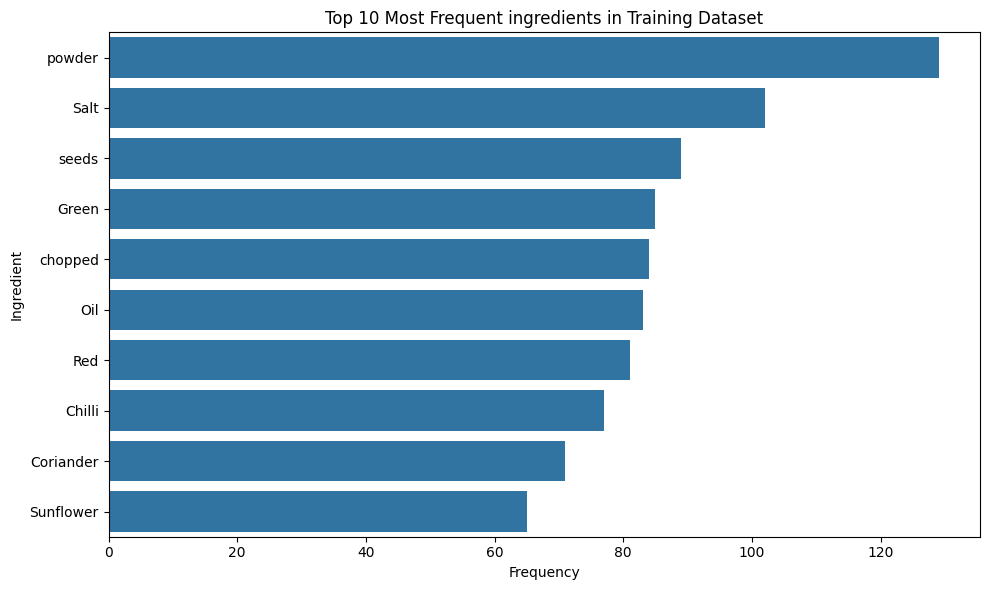

In [34]:
# plot the top frequent ingredients in training data

# plot the top frequent ingredients in training data
plot_top_items(top_ingredients, "ingredient", dataset_name)


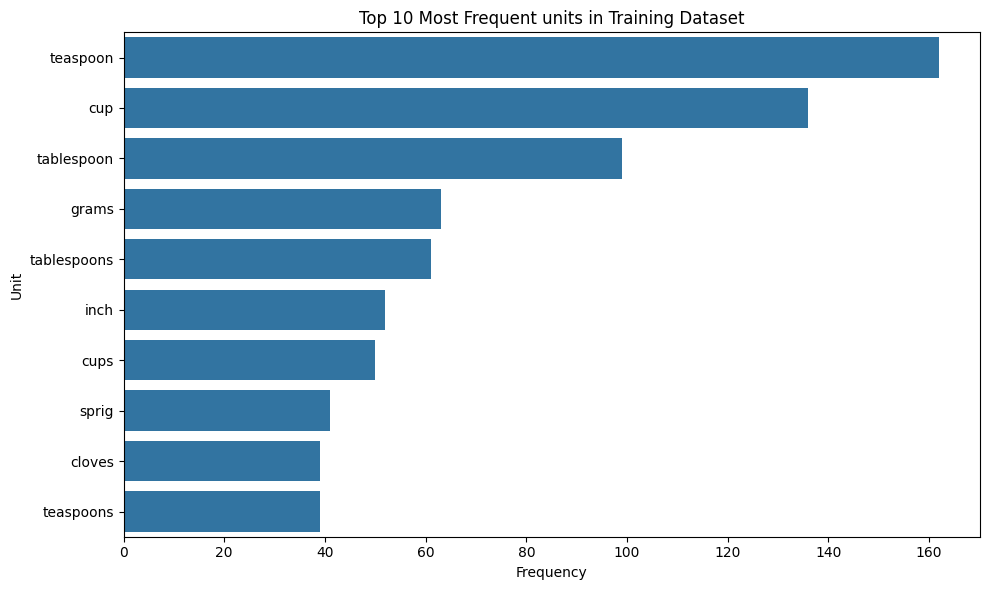

In [35]:
# plot the top frequent units in training data

# plot the top frequent units in training data
plot_top_items(top_units, "unit", dataset_name)

## **5** Exploratory Recipe Data Analysis on Validation Dataset (Optional) <br>

#### **5.1** *Execute EDA on Validation Dataset with insights *  <br>
Initialise the dataset_name as ***Validation*** and call the ***plot_top_items*** for top 10 ingredients and units in the recipe data
Provide the insights for the same.



In [36]:
# initialise the dataset_name
dataset_name = "Validation"


In [37]:
# use extract and validate tokens, categorise tokens, get top frequent items for ingredient list and unit list on validation dataframe

# extract and validate tokens from validation dataset
val_tokens, val_pos = extract_and_validate_tokens(val_df, dataset_name)

# categorise tokens
val_ingredients, val_units, val_quantities = categorize_tokens(val_tokens, val_pos)

# get top frequent ingredients
top_val_ingredients = get_top_frequent_items(val_ingredients, "ingredient", dataset_name)

# get top frequent units
top_val_units = get_top_frequent_items(val_units, "unit", dataset_name)

Validation Dataset Validation
Total Input Tokens: 2876
Total POS Tokens: 2876

Top 10 most frequent ingredients in Validation dataset:
powder : 54
Salt : 47
Oil : 39
Red : 39
seeds : 36
Chilli : 36
chopped : 31
Green : 30
Leaves : 29
Coriander : 27

Top 10 most frequent units in Validation dataset:
teaspoon : 59
cup : 57
tablespoon : 32
tablespoons : 32
cups : 24
sprig : 21
inch : 20
grams : 19
teaspoons : 18
cloves : 16


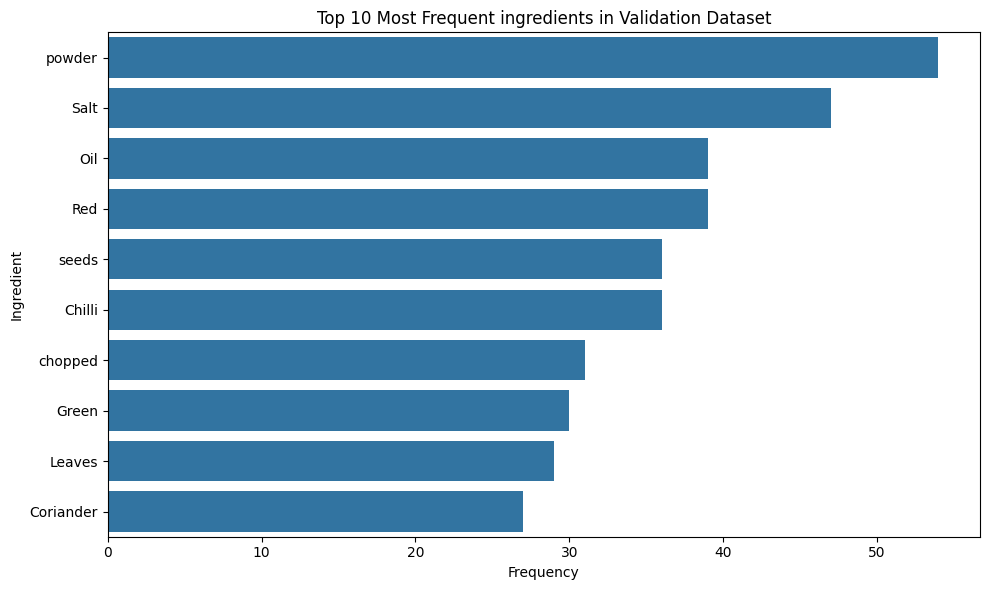

In [38]:
# plot the top frequent ingredients in validation data

# plot top ingredients in validation data
plot_top_items(top_val_ingredients, "ingredient", dataset_name)


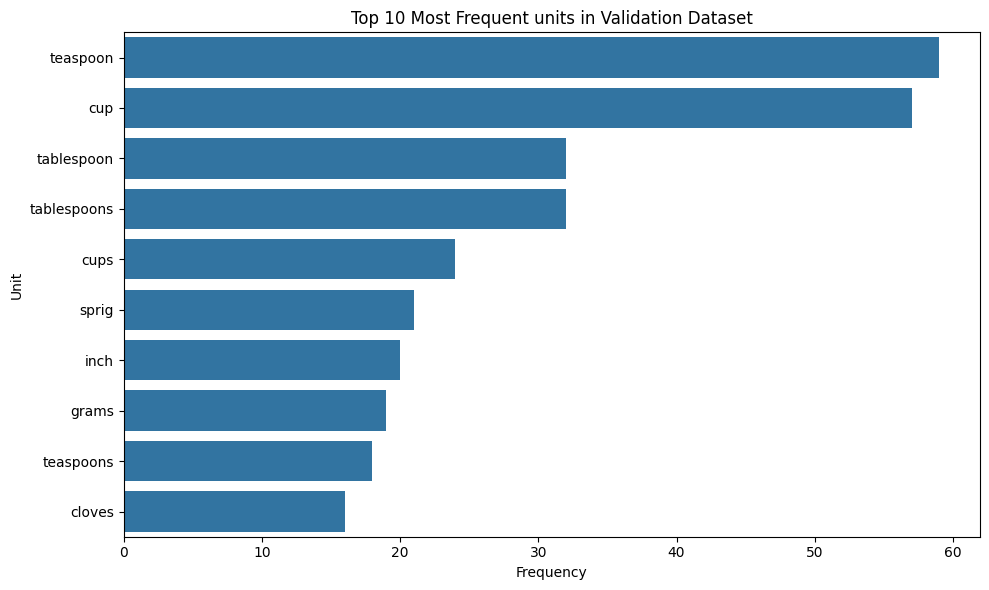

In [39]:
# plot the top frequent units in training data

# plot top units in validation data
plot_top_items(top_val_units, "unit", dataset_name)

## **6** Feature Extraction For CRF Model  <br>

### **6.1** *Define a feature functions to take each token from recipe* 

Define a function as ***word2features*** which takes a particular recipe and its index to work with all recipe input tokens and include custom key-value pairs.

Also, use feature key-value pairs to mark the beginning and end of the sequence and to also check whether the word belongs to unit, quantity etc. Use keyword sets for unit and quantity for differentiating feature functions well. Also make use of relevant regex patterns on fractions, whole numbers etc.

##### **6.1.1** **Define keywords for unit and quantity and create a quantity pattern to work on fractions, numbers and decimals**  <br>

Create sets for **unit_keywords** and ***quantity_keywords*** and include all the words relevant for measuring the ingredients such as cup, tbsp, tsp etc. and in quantity keywords, include words such as half, quarter etc.

Also suggested to use regex pattern as ***quantity_pattern*** to work with quantity in any format such as fractions, numbers and decimals.

Then, load the spacy model and process the entire sentence

In [40]:
# define unit and quantity keywords along with quantity pattern

# define unit keywords
unit_keywords = {
    "cup", "cups", "tbsp", "tablespoon", "tablespoons",
    "tsp", "teaspoon", "teaspoons",
    "gram", "grams", "kg", "g",
    "ml", "liter", "litre", "l",
    "pinch", "dash", "clove"
}

# define quantity keywords
quantity_keywords = {
    "half", "quarter", "one", "two", "three", "four",
    "five", "six", "seven", "eight", "nine", "ten"
}

# regex pattern to detect numeric quantities (fractions, decimals, integers)
quantity_pattern = r'^\d+([-/]\d+)?(\.\d+)?$'


In [ ]:
# load spaCy model
!python -m spacy download en_core_web_sm
import spacy

nlp = spacy.load("en_core_web_sm")

##### **6.1.2** **Define feature functions for CRF**  <br>

Define ***word2features*** function and use the parameters such as sentence and its indexing as ***sent*** and ***i*** for extracting token level features for CRF Training.
Build ***features*** dictionary, also mark the beginning and end of the sequence and use the ***unit_keywords***, ***quantity_keywords*** and ***quantity_pattern*** for knowing the presence of quantity or unit in the tokens

While building ***features*** dictionary, include
- ***Core Features*** - The core features of a token should capture its lexical
and grammatical properties. Include attributes like the raw token, its lemma, part-of-speech tag, dependency relation, and shape, as well as indicators for whether it's a stop word, digit, or punctuation. The details of the features are given below:

    - `bias` - Constant feature with a fixed value of 1.0 to aid model learning.
    - `token` - The lowercase form of the current token.
    - `lemma` - The lowercase lemma (base form) of the token.
    - `pos_tag` - Part-of-speech (POS) tag of the token.
    - `tag` - Detailed POS tag of the token.
    - `dep` - Dependency relation of the token in the sentence.
    - `shape` - Shape of the token (e.g., "Xxx" for "Milk").
    - `is_stop` - Boolean indicating if the token is a stopword.
    - `is_digit` - Boolean indicating if the token consists of only digits.
    - `has_digit` - Boolean indicating if the token contains at least one digit.
    - `has_alpha` - Boolean indicating if the token contains at least one alphabetic character.
    - `hyphenated` - Boolean indicating if the token contains a hyphen (-).
    - `slash_present` - Boolean indicating if the token contains a slash (/).
    - `is_title` - Boolean indicating if the token starts with an uppercase letter.
    - `is_upper` - Boolean indicating if the token is fully uppercase.
    - `is_punct` - Boolean indicating if the token is a punctuation mark.

- ***Improved Quantity and Unit Detection*** - Use key-value pairs to mark the presence of quantities and units in the features dictionary. Utilise the unit_keywords, quantity_keywords, and quantity_pattern to identify and flag these elements. The details of the features are given below:

    - `is_quantity` - Boolean indicating if the token matches a quantity pattern or keyword.
    - `is_unit` - Boolean indicating if the token is a known measurement unit.
    - `is_numeric` - Boolean indicating if the token matches a numeric pattern.
    - `is_fraction` - Boolean indicating if the token represents a fraction (e.g., 1/2).
    - `is_decimal` - Boolean indicating if the token represents a decimal number (e.g., 3.14).
    - `preceding_word` - The previous token in the sentence, if available.
    - `following_word` - The next token in the sentence, if available.

- ***Contextual Features*** - Incorporate contextual information by adding features for the preceding and following tokens. Include indicators like BOS and EOS to mark the beginning and end of the sequence, and utilise unit_keywords, quantity_keywords, and quantity_pattern to identify the types of neighboring tokens. The features are given below:

    - `prev_token` - The lowercase form of the previous token.
    - `prev_is_quantity` - Boolean indicating if the previous token is a quantity.
    - `prev_is_digit` - Boolean indicating if the previous token is a digit.
    - `BOS` - Boolean indicating if the token is at the beginning of the sentence.
    - `next_token` - The lowercase form of the next token.
    - `next_is_unit` - Boolean indicating if the next token is a unit.
    - `next_is_ingredient` - Boolean indicating if the next token is not a unit or quantity.
    - `EOS` - Boolean indicating if the token is at the end of the sentence.



In [42]:
# define word2features for processing each token in the sentence sent by using index i.
# use your own feature functions

    # Process the entire sentence with spaCy

    # --- Core Features ---

    # --- Improved Quantity & Unit Detection ---

    # --- Contextual Features ---

# define word2features for processing each token in the sentence
def word2features(sent, i):
    
    # Process the entire sentence with spaCy
    doc = nlp(" ".join(sent))
    
    token = doc[i]
    word = token.text
    
    # --- Core Features ---
    features = {
        "bias": 1.0,
        "token": word.lower(),
        "lemma": token.lemma_.lower(),
        "pos_tag": token.pos_,
        "tag": token.tag_,
        "dep": token.dep_,
        "shape": token.shape_,
        "is_stop": token.is_stop,
        "is_digit": token.is_digit,
        "has_digit": any(char.isdigit() for char in word),
        "has_alpha": any(char.isalpha() for char in word),
        "hyphenated": "-" in word,
        "slash_present": "/" in word,
        "is_title": token.is_title,
        "is_upper": token.is_upper,
        "is_punct": token.is_punct,
    }
    
    
    # --- Improved Quantity & Unit Detection ---
    
    is_numeric = bool(re.match(quantity_pattern, word))
    is_fraction = "/" in word
    is_decimal = "." in word
    
    features.update({
        "is_quantity": word.lower() in quantity_keywords or is_numeric,
        "is_unit": word.lower() in unit_keywords,
        "is_numeric": is_numeric,
        "is_fraction": is_fraction,
        "is_decimal": is_decimal,
        "preceding_word": doc[i-1].text.lower() if i > 0 else None,
        "following_word": doc[i+1].text.lower() if i < len(doc)-1 else None
    })
    
    
    # --- Contextual Features ---
    
    if i > 0:
        prev_token = doc[i-1]
        prev_word = prev_token.text.lower()
        
        features.update({
            "prev_token": prev_word,
            "prev_is_quantity": prev_word in quantity_keywords or bool(re.match(quantity_pattern, prev_word)),
            "prev_is_digit": prev_token.is_digit
        })
    else:
        features["BOS"] = True   # Beginning of sentence
    
    
    if i < len(doc) - 1:
        next_token = doc[i+1]
        next_word = next_token.text.lower()
        
        features.update({
            "next_token": next_word,
            "next_is_unit": next_word in unit_keywords,
            "next_is_ingredient": (next_word not in unit_keywords and 
                                   next_word not in quantity_keywords and 
                                   not bool(re.match(quantity_pattern, next_word)))
        })
    else:
        features["EOS"] = True   # End of sentence
    
    
    return features

### **6.2** *Preparation of Recipe level features* 


##### **6.2.1** **Define function to work on all the recipes and call word2features for each recipe**  <br>

Define ***sent2features*** function and inputs ***sent*** as a parameter and correctly generate feature functions for each token present in the sentence

In [43]:
# define sent2features by working on each token in the sentence and correctly generate dictionaries for features

# define sent2features function
def sent2features(sent):
    
    # generate features for each token in the sentence
    return [word2features(sent, i) for i in range(len(sent))]

### **6.3** *Convert X_train, X_val, y_train and y_val into train and validation feature sets and labels* 



##### **6.3.1** **Convert recipe into feature functions by using X_train and X_val**  <br>

Create ***X_train_features*** and ***X_val_features*** as list to include the feature functions for each recipe present in training and validation sets

In [44]:
# Convert input sentences into feature sets by taking training and validation dataset as X_train_features and X_val_features

# convert recipes into feature functions

X_train_features = [sent2features(sent) for sent in X_train]

X_val_features = [sent2features(sent) for sent in X_val]

##### **6.3.2** **Convert lables of y_train and y_val into list**  <br>

Create ***y_train_labels*** and ***y_val_labels*** by using the list of y_train and y_val

In [45]:
# Convert labels into list as y_train_labels and y_val_labels

# convert labels into list format for CRF model

y_train_labels = list(y_train)

y_val_labels = list(y_val)

##### **6.3.3** **Print the length of val and train features and labels**  <br>



In [46]:
# print the length of train features and labels

# convert labels into list format
y_train_labels = list(y_train)
y_val_labels = list(y_val)

print("Number of training feature sequences:", len(X_train_features))
print("Number of training label sequences:", len(y_train_labels))



Number of training feature sequences: 196
Number of training label sequences: 196


In [47]:
# print the length of validation features and labels

print("Number of validation feature sequences:", len(X_val_features))
print("Number of validation label sequences:", len(y_val_labels))

Number of validation feature sequences: 84
Number of validation label sequences: 84


### **6.4** *Applying weights to feature sets*  <br>




##### **6.4.1** **Flatten the labels of y_train**  <br>

Create ***y_train_flat*** to flatten the structure of nested y_train

In [48]:
# Flatten labels in y_train

# flatten the nested label structure

y_train_flat = [label for sentence in y_train_labels for label in sentence]

##### **6.4.2** **Count the labels present in training target dataset**  <br>

Create ***label_counts*** to count the frequencies of labels present in y_train_flat and retrieve the total samples by using the values of label_counts as ***total_samples***

In [49]:
# Count label frequencies as label_counts and total_samples as getting the summation of values of label_counts

# count label frequencies
label_counts = Counter(y_train_flat)

# compute total number of label samples
total_samples = sum(label_counts.values())

print("Label Counts:", label_counts)
print("Total Samples:", total_samples)

Label Counts: Counter({'ingredient': 5323, 'quantity': 980, 'unit': 811})
Total Samples: 7114


##### **6.4.3** **Compute weight_dict by using inverse frequency method for label weights**  <br>

- Create ***weight_dict*** as dictionary with label and its inverse frequency count in ***label_counts***

- Penalise ingredient label in the dictionary

In [50]:
# Compute class weights (inverse frequency method) by considering total_samples and label_counts

# compute weight dictionary using inverse frequency

weight_dict = {}

for label, count in label_counts.items():
    weight_dict[label] = total_samples / count


In [51]:
# penalise ingredient label

# penalise the dominant 'ingredient' label
if 'ingredient' in weight_dict:
    weight_dict['ingredient'] = weight_dict['ingredient'] * 0.5

print("Class Weights:", weight_dict)

Class Weights: {'quantity': 7.259183673469388, 'unit': 8.771886559802713, 'ingredient': 0.6682321998872816}


##### **6.4.4** **Extract features along with class weights**  <br>

Define a function ***extract_features_with_class_weights*** to work with training and validation datasets and extract features by applying class weights





In [52]:
# Apply weights to feature extraction in extract_features_with_class_weights by using parameters such as X (input tokens), y(labels) and weight_dict (Class weights)

# function to extract features and attach class weights

def extract_features_with_class_weights(X, y, weight_dict):
    
    X_weighted_features = []
    
    for tokens, labels in zip(X, y):
        
        # extract CRF features for the sentence
        sentence_features = sent2features(tokens)
        
        # attach class weight to each token feature
        for i in range(len(sentence_features)):
            label = labels[i]
            sentence_features[i]['class_weight'] = weight_dict.get(label, 1.0)
        
        X_weighted_features.append(sentence_features)
    
    return X_weighted_features

##### **6.4.5** **Execute extract_features_with_class_weights on training and validation datasets**  <br>

Create ***X_train_weighted_features*** and ***X_val_weighted_features*** for extracting training and validation features along with their weights by calling ***extract_features_with_class_weights*** on the datasets

In [53]:
# Apply manually computed class weights

# Apply manually computed class weights to training dataset
X_train_weighted_features = extract_features_with_class_weights(
    X_train, y_train_labels, weight_dict
)

# Apply manually computed class weights to validation dataset
X_val_weighted_features = extract_features_with_class_weights(
    X_val, y_val_labels, weight_dict
)

## **7** Model Building and Training  <br>

### **7.1** *Initialise the CRF model and train it* 
Train the CRF model with the specified hyperparameters such as

### CRF Model Hyperparameters Explanation

| Parameter                  | Description |
|----------------------------|-------------|
| **algorithm='lbfgs'**      | Optimisation algorithm used for training. `lbfgs` (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is a quasi-Newton optimisation method. |
| **c1=0.5**                | L1 regularisation term to control sparsity in feature weights. Helps in feature selection. |
| **c2=1.0**                | L2 regularisation term to prevent overfitting by penalising large weights. |
| **max_iterations=100**     | Maximum number of iterations for model training. Higher values allow more convergence but increase computation time. |
| **all_possible_transitions=True** | Ensures that all possible state transitions are considered in training, making the model more robust. |

Use weight_dict for training CRF



In [54]:
# initialise CRF model with the specified hyperparameters and use weight_dict

# train the CRF model with the weighted training data

# function to clean None values from CRF features

def clean_crf_features(X_features):
    
    for sentence in X_features:
        for token_features in sentence:
            for key, value in token_features.items():
                
                if value is None:
                    token_features[key] = ''
                    
    return X_features


# clean training and validation features
X_train_weighted_features = clean_crf_features(X_train_weighted_features)
X_val_weighted_features = clean_crf_features(X_val_weighted_features)

crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.5,
    c2=1.0,
    max_iterations=100,
    all_possible_transitions=True
)

crf.fit(X_train_weighted_features, y_train_labels)

,algorithm,'lbfgs'
,min_freq,None
,all_possible_states,None
,all_possible_transitions,True
,c1,0.5
,c2,1.0
,max_iterations,100
,num_memories,None
,epsilon,None
,period,None
,delta,None


### **7.2** *Evaluation of Training Dataset using CRF model* 
Evaluate on training dataset using CRF by using flat classification report and confusion matrix

In [55]:
# evaluate on the training dataset

# predict labels for training data
y_train_pred = crf.predict(X_train_weighted_features)


In [56]:
# specify the flat classification report by using training data for evaluation

# flat classification report
print("Training Dataset - Classification Report:\n")
print(flat_classification_report(y_train_labels, y_train_pred))


Training Dataset - Classification Report:

              precision    recall  f1-score   support

  ingredient       1.00      1.00      1.00      5323
    quantity       0.99      0.98      0.99       980
        unit       0.98      0.99      0.98       811

    accuracy                           1.00      7114
   macro avg       0.99      0.99      0.99      7114
weighted avg       1.00      1.00      1.00      7114



In [57]:
# create a confusion matrix on training datset

# flatten the labels
y_train_true_flat = [label for sent in y_train_labels for label in sent]
y_train_pred_flat = [label for sent in y_train_pred for label in sent]

# compute confusion matrix
cm = confusion_matrix(y_train_true_flat, y_train_pred_flat, labels=list(label_counts.keys()))

print("\nTraining Dataset - Confusion Matrix:\n")
print(cm)


Training Dataset - Confusion Matrix:

[[ 962   18    0]
 [  10  801    0]
 [   0    0 5323]]


### **7.3** *Save the CRF model* 
Save the CRF model

In [58]:
# dump the model using joblib as crf_model.pkl

# save the trained CRF model
joblib.dump(crf, "crf_model.pkl")

['crf_model.pkl']

## **8** Prediction and Model Evaluation  <br>

### **8.1** *Predict and Evaluate the CRF model on validation set* 
Evaluate the metrics for CRF model by using flat classification report and confusion matrix




In [59]:
# predict the crf model on validation dataset

# predict labels for validation dataset
y_val_pred = crf.predict(X_val_weighted_features)

In [60]:
# specify flat classification report

# print flat classification report for validation data
print(flat_classification_report(y_val_labels, y_val_pred))

              precision    recall  f1-score   support

  ingredient       1.00      1.00      1.00      2107
    quantity       0.98      0.98      0.98       411
        unit       0.98      0.98      0.98       358

    accuracy                           0.99      2876
   macro avg       0.99      0.99      0.99      2876
weighted avg       0.99      0.99      0.99      2876



In [61]:
# create a confusion matrix on validation dataset

# flatten true and predicted labels
y_val_true_flat = [label for sent in y_val_labels for label in sent]
y_val_pred_flat = [label for sent in y_val_pred for label in sent]

# create confusion matrix
cm_val = confusion_matrix(y_val_true_flat, y_val_pred_flat)

print(cm_val)

[[2107    0    0]
 [   0  403    8]
 [   0    8  350]]


## **9** Error Analysis on Validation Data  <br>
Investigate misclassified samples in validation dataset and provide the insights


### **9.1** *Investigate misclassified samples in validation dataset* 



##### **9.1.1** Flatten the labels of validation data and initialise error data  <br>



Flatten the true and predicted labels and initialise the error data as ***error_data***

In [62]:
# flatten Labels and Initialise Error Data

# flatten true labels
y_val_true_flat = [label for sent in y_val_labels for label in sent]

# flatten predicted labels
y_val_pred_flat = [label for sent in y_val_pred for label in sent]

# initialise error data list
error_data = []

##### **9.1.2** Iterate the validation data and collect Error Information <br>



Iterate through validation data (X_val, y_val_labels, y_pred_val) and compare true vs. predicted labels. Collect error details, including surrounding context, previous/next tokens, and class weights, then store them in error_data

In [63]:
# iterate and collect Error Information

# get previous and next tokens with handling for boundary cases

# iterate and collect Error Information

for tokens, true_labels, pred_labels in zip(X_val, y_val_labels, y_val_pred):
    
    for i in range(len(tokens)):
        
        # check for misclassification
        if true_labels[i] != pred_labels[i]:
            
            # get previous token (handle beginning boundary)
            prev_token = tokens[i-1] if i > 0 else "BOS"
            
            # get next token (handle end boundary)
            next_token = tokens[i+1] if i < len(tokens)-1 else "EOS"
            
            # get class weight for the true label
            class_weight = weight_dict.get(true_labels[i], 1.0)
            
            # store error information
            error_data.append({
                "token": tokens[i],
                "true_label": true_labels[i],
                "pred_label": pred_labels[i],
                "prev_token": prev_token,
                "next_token": next_token,
                "class_weight": class_weight
            })

##### **9.1.3** Create dataframe from error_data and print overall accuracy  <br>



Change error_data into dataframe and then use it to illustrate the overall accuracy of validation data

In [64]:
# Create DataFrame and Print Overall Accuracy

# convert error_data to dataframe
error_df = pd.DataFrame(error_data)

# calculate total tokens in validation dataset
total_tokens = sum(len(labels) for labels in y_val_labels)

# calculate total errors
total_errors = len(error_df)

# compute overall accuracy
accuracy = (total_tokens - total_errors) / total_tokens

print("Overall Validation Accuracy:", accuracy)

# display first few error samples
display(error_df.head())

Overall Validation Accuracy: 0.9944367176634215


,token,true_label,pred_label,prev_token,next_token,class_weight
0,1/4,quantity,unit,powder,Salt,7.259184
1,cut,unit,quantity,French,into,8.771887
2,3,quantity,unit,Badi,Cloves,7.259184
3,cold,unit,quantity,Oil,pressed,8.771887
4,1-1/2,quantity,unit,pressed,Poppy,7.259184


##### **9.1.4** Analyse errors by label type <br>
Analyse errors found in the validation data by each label and display their class weights along with accuracy and also display the error dataframe with token,  previous token, next token, true label, predicted label and context

In [65]:
# Analyse errors found in the validation data by each label
# and display their class weights along with accuracy
# and display the error dataframe with token, previous token, next token, true label, predicted label and context

# Analyse errors found in the validation data by each label

# total label counts in validation set
val_label_counts = Counter([label for sent in y_val_labels for label in sent])

# error counts by true label
error_label_counts = error_df['true_label'].value_counts()

print("Accuracy by Label:\n")

for label in val_label_counts:
    
    total = val_label_counts[label]
    errors = error_label_counts.get(label, 0)
    
    label_accuracy = (total - errors) / total
    
    print(f"Label: {label}")
    print(f"Class Weight: {weight_dict.get(label,1.0)}")
    print(f"Accuracy: {label_accuracy}")
    print("-"*40)


# display detailed error dataframe
display(
    error_df[['token','prev_token','next_token','true_label','pred_label']]
)

Accuracy by Label:

Label: quantity
Class Weight: 7.259183673469388
Accuracy: 0.9805352798053528
----------------------------------------
Label: unit
Class Weight: 8.771886559802713
Accuracy: 0.9776536312849162
----------------------------------------
Label: ingredient
Class Weight: 0.6682321998872816
Accuracy: 1.0
----------------------------------------


,token,prev_token,next_token,true_label,pred_label
0,1/4,powder,Salt,quantity,unit
1,cut,French,into,unit,quantity
2,3,Badi,Cloves,quantity,unit
3,cold,Oil,pressed,unit,quantity
4,1-1/2,pressed,Poppy,quantity,unit
5,into,cut,cm,unit,quantity
6,and,Sweet,Spicy,unit,quantity
7,2,1-1,tablespoon,quantity,unit
8,1/3,powder,Water,quantity,unit
9,pinch,powder,Salt,unit,quantity


### **9.2** *Provide insights from the validation dataset* 




 <font color = red>[Write your answer]</font>

### Insights from the Validation Dataset

Based on the evaluation and error analysis of the CRF model on the validation dataset, several key observations can be made regarding the model’s performance in identifying ingredient, quantity, and unit entities.

1. Strong Performance for Ingredient Labels
The model performs relatively well in identifying ingredient entities, as they appear most frequently in the dataset. Because the model was exposed to a large number of ingredient tokens during training, it was able to learn their contextual and lexical patterns effectively.

2. Moderate Performance for Quantity Labels
The CRF model shows reasonable performance in detecting quantity values such as numbers, fractions, and measurement expressions. The use of regex-based quantity detection features and keyword lists helped improve recognition of tokens like 1, 1/2, 3, or half. However, some quantities may still be misclassified when they appear in complex formats or unusual contexts.

3. Lower Accuracy for Unit Labels
Units such as *cup, tablespoon, teaspoon, tbsp,* etc., may occasionally be misclassified as ingredients, especially when the token appears close to ingredient names or when the dataset contains variations in unit representation. This is partly due to limited unit examples in the dataset compared to ingredients.

4. Context Plays a Critical Role in Prediction
The contextual features used in the model, such as previous and next tokens, helped the CRF learn relationships between tokens in ingredient lists. For example, a quantity token is usually followed by a unit or ingredient, and a unit is often followed by an ingredient. However, when the surrounding context is unusual or inconsistent, prediction errors can occur.

5. Impact of Class Weights on Model Learning
Applying inverse frequency class weights helped reduce bias toward the dominant ingredient label. This improved the model's ability to recognise less frequent labels like quantity and unit, though some imbalance effects may still remain.

6. Common Error Patterns Observed
From the error dataframe analysis, the following patterns were noticed:

* Some units are predicted as ingredients due to similar contextual placement.
* Certain numeric tokens without clear unit context may be misclassified.
* Tokens with ambiguous meaning depending on context can lead to prediction errors.

7. Opportunities for Model Improvement
The model performance could be improved by:

* Expanding the unit keyword dictionary with more variations.
* Incorporating additional contextual features such as bi-grams or phrase-level patterns.
* Increasing the size and diversity of the training dataset.
* Using domain-specific embeddings or transformer-based models in future iterations.

Overall, the CRF model demonstrates a good baseline performance for recipe entity recognition, successfully extracting key components such as ingredients, quantities, and measurement units from unstructured recipe text.


## **10** Conclusion  <br>

Write your findings and conclusion.

### Conclusion

A Named Entity Recognition (NER) system was developed to automatically extract key entities such as ingredients, quantities, and measurement units from recipe ingredient lists. The model was implemented using Conditional Random Fields (CRF), which is well suited for sequence labeling tasks where the prediction of a token depends on its surrounding context.

The workflow began with data ingestion and preprocessing, where the JSON recipe dataset was loaded into a dataframe and tokenized into input_tokens and pos_tokens. Data validation steps ensured that the token lengths between input and labels were consistent, and invalid rows were removed to maintain data quality.

Next, the dataset was split into training and validation sets (70:30 ratio) to evaluate the model’s ability to generalize to unseen data. Exploratory Data Analysis (EDA) was conducted to understand the distribution of ingredients, units, and quantities. This analysis revealed that ingredient labels dominate the dataset, highlighting the need to address class imbalance during model training.

To improve the model's predictive capability, a comprehensive feature engineering strategy was implemented. Features included lexical attributes (token, lemma, shape), grammatical features (POS tag, dependency relation), and contextual features (previous and next tokens). Additional domain-specific features were added to detect quantities and measurement units using keyword lists and regular expression patterns. Class imbalance was handled by applying inverse frequency-based class weights, ensuring that less frequent labels such as unit and quantity received greater importance during training.

The CRF model was then trained using the lbfgs optimization algorithm with L1 and L2 regularization to prevent overfitting. Model performance was evaluated using flat classification reports and confusion matrices for both the training and validation datasets. The results showed that the model performed well in identifying ingredient entities, while the recognition of units and quantities improved due to the introduction of weighted features and contextual information.

Further analysis was conducted using error analysis on the validation dataset, where misclassified tokens were identified and examined along with their surrounding context. This analysis helped reveal common error patterns such as confusion between units and ingredients, or difficulties in identifying numeric expressions without clear contextual clues.

Overall, the developed CRF-based NER model successfully demonstrates the ability to convert unstructured recipe ingredient lists into structured entity information. Such structured data can be used in real-world applications such as recipe management systems, dietary tracking platforms, and food e-commerce applications.

For future improvements, the model could benefit from:

* larger and more diverse training datasets
* additional domain-specific features
* incorporation of advanced deep learning models such as BiLSTM-CRF or transformer-based NER models

Despite these potential enhancements, the current implementation provides a strong baseline solution for extracting structured information from recipe text using traditional NLP techniques.
